# 2. Data and Clear Data
In the previous notebook, "first analysis data," we examined the data as follows:  
1. Data type  
2. Data issues and problems  
3. Comparing data with each other  
4. Plotting charts from the data  
5. Assessing the data distribution to determine if it is normal or not  
6. Analyzing data behavior before movement, during movement, and after movement  
7. Identifying the type of movement and the dominant foot (which foot bears the most force and pulls the movement toward itself)  
8. Examining movement behavior  

In [2]:
#basic
import os
import math
import gpxpy # read .GPX
from pathlib import Path
from datetime import datetime # datetime

#analysis
import numpy as np
import pandas as pd

#Statistik
import scipy.stats as stats

#plot
import matplotlib.pyplot as plt
import seaborn as sns

one file for sampel

In [2]:
# file_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2)/loadsolASCII_25-11-11 09-38-11-074_Asphalt.txt"
file_path =  r"C:/Users/user/Desktop/Fatemeh/Force data (novel loadsol 2)/Force data (novel loadsol 2)/loadsolASCII_25-11-17 10-09-36-341.txt"

with open(file_path, 'r', encoding='utf-8') as f:
    first_two_lines = [next(f) for _ in range(2)]

for i, line in enumerate(first_two_lines, 1):
    print(f"line {i}: {line.rstrip()}")

# name file
print(first_two_lines[0][5:].replace(".pdo\n",""))
# name Type of surface and last number
print(first_two_lines[1][8:].replace("\n","").split("_"))

line 1: File: loadsol_25-11-17 10-09-36-341.pdo
line 2: Comment:S07_Asphalt_01
 loadsol_25-11-17 10-09-36-341
['S07', 'Asphalt', '01']


# Force Data of Foot

In [11]:
# file_path =  r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2)/loadsolASCII_25-11-17 10-09-36-341.txt"
file_path =  r"C:/Users/user/Desktop/Fatemeh/Force data (novel loadsol 2)/Force data (novel loadsol 2)/loadsolASCII_25-11-17 10-09-36-341.txt"


# Fynction Format Time
def format_timedelta(td):
    """format_timedelta Format Of time
    read time and format hh:mm:ss.ss
    13:51:48.01
    """
    if pd.isna(td):
        return None
    total_seconds = int(td.total_seconds())
    microseconds = td.microseconds
    # mili seconds = microseconds // 1000
    # Canti second (2 decimal) = round(microseconds / 10000)
    centiseconds = round(td.microseconds / 10000)  # 2 decimal
    if centiseconds == 100:
        centiseconds = 0
        total_seconds += 1
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}.{centiseconds:02d}"


# make datafaram as text and clear data
def make_dataframe(path):
    """find data in text
    Data = read file
    path = path of file
    line1 = 1st line name of file
    line2 = 2st line name of person and surface and one number
    line3 = 3rd line name of columns
    line4 = 4th line name of columns
    """
    #read data and line 1,2 ,3 4
    with open(path, "r", encoding="utf-8") as f:
        line1 = f.readline().rstrip("\n")
        line2 = f.readline().rstrip("\n")
        line3 = f.readline().rstrip("\n")
        line4 = f.readline().rstrip("\n")
    # date and Time of start
    date_ = (f"20{line1[14:-8][0:8]}").replace("-", "_")
    Start_Time = (f"{line1[23:-8][0:8]}").replace("-", "_")
    # line 1 and 2 and make name of columns
    a1 = np.array(line3.split("\t"))
    a2 = np.array(line4.split("\t"))[0:len(a1)]
    b = a1 + a2
    # replace name of columns
    name_colunms = np.char.replace(b, "Force[N]", "")
    name_colunms = np.char.replace(name_colunms, "::", "_")
    name_colunms = np.char.replace(name_colunms, "-", "_")
    #clear name of colums
    left_L =[]
    right_R = []
    for i in range(len(name_colunms)):
        left_L.append(name_colunms[i].rfind("_L"))
        right_R.append(name_colunms[i].rfind("_R"))
    for j in range(len(name_colunms)):
        if left_L[j] > 0:
            name_colunms[j] = name_colunms[j][left_L[j]+1:]
        elif right_R[j]>0:
            name_colunms[j] = name_colunms[j][right_R[j]+1:]
    name_colunms = np.char.replace(name_colunms, "L ", "L")
    # make name of dataframe
    name = line1[-7:-4]
    person_surface_number = line2[8:].split("_")
    main_name = (person_surface_number[1] + "_Foot_" +
                 person_surface_number[0]+ "_" +
                 person_surface_number[2]+ "_" +
                 name+ "_Date_"+
                 date_+"_Time_"+
                 Start_Time)
    #read row 5 to end of data
    df = pd.read_csv(path,
                     skiprows=4,
                     sep=r"\s+",
                     decimal=",",
                     header=None)
    # rename columns of dataframe
    df.columns = name_colunms.tolist()
    df = df.rename(columns={"L":"Total_L_Foot", "R":"Total_R_Foot"})
    # drop and make time
    Time = np.arange(len(df)) * 0.01
    df = df.drop(columns="Time[secs]")
    df.insert(loc=0, column='Time', value=Time)
    #raplace -1 to 0
    df = df.replace(-1, 0)
    # make columns missed
    if len(df.columns)== 7:
        df.insert(loc=2, column= "L_Midfoot", value=0)
        df.insert(loc=6, column= "R_Midfoot", value=0)
    df.insert(loc=0, column= "Date", value=date_.replace("_", "-"))
    df.insert(loc=1, column= "Start_Time", value=Start_Time.replace("_", ":"))
    # make time of each location
    df.insert(loc=2, column= "Time_Running", value=(pd.to_timedelta((pd.to_timedelta(df["Start_Time"]))+
                                                 pd.to_timedelta(df["Time"],unit='s'))
                                                 .apply(format_timedelta)))


    return  name, person_surface_number, name_colunms, main_name , df

# q ,w,  s , z, x= make_dataframe(file_path)
# globals()[z] = x
# globals()[z]

# make_dataframe(file_path)
name ,person_surface_number, name_colunms, main_name, data_frame= make_dataframe(file_path)

data_frame

,Date,Start_Time,Time_Running,Time,L_Heel,L_Midfoot,L_Forefoot,Total_L_Foot,R_Forefoot,R_Midfoot,R_Heel,Total_R_Foot
0,2025-11-17,10:09:36,10:09:36.00,0.00,160.65,0,630.00,790.65,2.50,0,0.00,2.50
1,2025-11-17,10:09:36,10:09:36.01,0.01,148.05,0,642.60,790.65,0.00,0,0.00,0.00
2,2025-11-17,10:09:36,10:09:36.02,0.02,129.15,0,661.50,790.65,0.00,0,0.00,0.00
3,2025-11-17,10:09:36,10:09:36.03,0.03,113.40,0,677.25,790.65,0.00,0,0.00,0.00
4,2025-11-17,10:09:36,10:09:36.04,0.04,94.50,0,686.70,781.20,0.00,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
46886,2025-11-17,10:09:36,10:17:24.86,468.86,13.65,0,581.49,595.14,74.37,0,137.35,211.72
46887,2025-11-17,10:09:36,10:17:24.87,468.87,5.46,0,570.57,576.03,82.41,0,139.36,221.77
46888,2025-11-17,10:09:36,10:17:24.88,468.88,0.00,0,554.19,554.19,87.10,0,147.40,234.50
46889,2025-11-17,10:09:36,10:17:24.89,468.89,0.00,0,540.54,540.54,97.15,0,157.45,254.60


Read all data - Force data Foot

In [12]:
# read data form
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main"
# save datafrom to folder as xlsx
output_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Clear data as CSV"

os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith('.txt')]

# test read data
# file_names[0]
# path = f"{input_path}/{file_names[0]}"
# q ,w,  s , z, x= make_dataframe(path)

if 'name' in globals():
    del name
if 'person_surface_number' in globals():
    del person_surface_number
if 'person_surface_number' in globals():
    del name_colunms
if 'main_name' in globals():
    del main_name
if 'data_frame' in globals():
    del data_frame

name_of_dataframe = []
for file_name in file_names:
    path = f"{input_path}/{file_name}"
    print(path)
    name ,person_surface_number, name_colunms, main_name, data_frame= make_dataframe(path)
    print(main_name)
    name_of_dataframe.append(main_name)
    globals()[main_name] = data_frame
    # save data as CSV
    # output_file = os.path.join(output_path, f"{main_name}.csv")
    # globals()[main_name].to_csv(output_file, index=False)


C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main/loadsolASCII_25-11-11 09-24-19-079.txt
Gravel_Foot_P02_01_079_Date_2025_11_11_Time_09_24_19
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main/loadsolASCII_25-11-11 09-38-11-074.txt
Asphalt_Foot_P02_01_074_Date_2025_11_11_Time_09_38_11
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main/loadsolASCII_25-11-11 09-52-01-474.txt
Sand_Foot_P02_01_474_Date_2025_11_11_Time_09_52_01
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main/loadsolASCII_25-11-11 10-06-34-305.txt
Grass_Foot_P02_01_305_Date_2025_11_11_Time_10_06_34
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Force data (novel loadsol 2) Main/loadsolASCII_25-11-11 10-09-51-519.txt
Grass_Foot_P02_

make dataframe : name of file foot and date and time

In [13]:
name_foot_df = pd.DataFrame(name_of_dataframe).rename(columns={0:"name of file"})
name_foot_df[['Date', 'Time']] = (name_foot_df['name of file']
                                  .str.extract(r'Date_(\d{4}_\d{2}_\d{2})_Time_(\d{2}_\d{2}_\d{2})'))
name_foot_df

,name of file,Date,Time
0,Gravel_Foot_P02_01_079_Date_2025_11_11_Time_09...,2025_11_11,09_24_19
1,Asphalt_Foot_P02_01_074_Date_2025_11_11_Time_0...,2025_11_11,09_38_11
2,Sand_Foot_P02_01_474_Date_2025_11_11_Time_09_5...,2025_11_11,09_52_01
3,Grass_Foot_P02_01_305_Date_2025_11_11_Time_10_...,2025_11_11,10_06_34
4,Grass_Foot_P02_02_519_Date_2025_11_11_Time_10_...,2025_11_11,10_09_51
5,Grass_Foot_S03_01_080_Date_2025_11_11_Time_13_...,2025_11_11,13_49_21
6,Grass_Foot_S03_02_511_Date_2025_11_11_Time_13_...,2025_11_11,13_54_44
7,Sand_Foot_S03_01_595_Date_2025_11_11_Time_14_0...,2025_11_11,14_09_23
8,Asphalt_Foot_S03_01_634_Date_2025_11_11_Time_1...,2025_11_11,14_21_20
9,Gravel_Foot_S03_01_974_Date_2025_11_11_Time_14...,2025_11_11,14_28_52


# Heartrate (Polar Ignite 2)

In [3]:
# Path Folder
folder_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)"
# file name
file_name = "Maximilian_Stasica_2025-11-16_14-48-22"
# path of file
full_file_path = f"{folder_path}/{file_name}.csv"
# read file
df = pd.read_csv(full_file_path)

In [4]:


folder_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)"
file_name = "Maximilian_Stasica_2025-11-16_14-48-22.GPX"
gpx_path = f"{folder_path}/{file_name}"

with open(gpx_path, 'r', encoding='utf-8') as f:
    gpx = gpxpy.parse(f)

data = []
for track in gpx.tracks:
    for segment in track.segments:
        for point in segment.points:
            data.append({
                'time': point.time,
                'latitude': point.latitude,
                'longitude': point.longitude,
                'elevation': point.elevation
            })

df = pd.DataFrame(data)

df

,time,latitude,longitude,elevation
0,2025-11-16 13:48:37.673000+00:00,49.895375,8.804597,375.0
1,2025-11-16 13:48:41.672000+00:00,49.895663,8.804450,368.0
2,2025-11-16 13:48:42.672000+00:00,49.895665,8.804505,363.0
3,2025-11-16 13:48:43.673000+00:00,49.895693,8.804558,355.0
4,2025-11-16 13:48:44.673000+00:00,49.895725,8.804515,347.0
...,...,...,...,...
4337,2025-11-16 15:00:57.673000+00:00,49.907630,8.808547,150.0
4338,2025-11-16 15:00:58.672000+00:00,49.907630,8.808547,150.0
4339,2025-11-16 15:00:59.672000+00:00,49.907630,8.808548,150.0
4340,2025-11-16 15:01:00.672000+00:00,49.907630,8.808548,150.0


# Read all data from Heartrate (Polar Ignite 2)

In [5]:
# read data form
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)"
# save datafrom to folder as xlsx
output_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Force data (novel loadsol 2)/Clear data as CSV"

os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith('.CSV')]
file_path = f"{input_path}/{file_names[0]}"
#---------------------
if 'name_of_dataframe_Heartrate' in globals():
    del name_of_dataframe_Heartrate


df_1_info = pd.read_csv(file_path, nrows=1)
df_2L_information = (df_1_info.T.stack(future_stack=True)
                     .reset_index().rename(columns={"level_0":"type name", 0:"value"})
                     .drop(columns="level_1"))
df_1_data = pd.read_csv(file_path, skiprows=2).drop(columns=["Sample rate", "Unnamed: 11"])
df_1_data.insert(loc=0, column="value", value=df_2L_information["value"].iloc[0])
df_1_data.insert(loc=0, column="type name", value=df_2L_information["value"].iloc[1])



In [7]:
# read data form
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)"
# save datafrom to folder as xlsx
output_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2) CSV"

os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith('.CSV')]

#---------------------

# make name of dataframe
new_name=[]
main_name = []
for i in range(len(file_names)):
    new_name.append(f"Heartrate_Date_{file_names[i][19:29]}_Time_{file_names[i][30:]}")
    main_name.append(file_names[i])

main_name = pd.DataFrame(main_name)
new_name = pd.DataFrame(new_name)
new_name = new_name.replace("-","_", regex=True).replace(".CSV","", regex=True)
new_name.insert(loc=0, column="main_name", value=main_name[0])
new_name = new_name.rename(columns={0:"df_name"})

name_of_dataframe_Heartrate = []
for i in range(len(new_name)):
    file_name = new_name["main_name"][i]
    df_name = new_name["df_name"][i]
    path = f"{input_path}/{file_name}"
    print(path)
    name_of_dataframe_Heartrate.append(df_name)
    df_1_info = pd.read_csv(path, nrows=1)
    df_2L_information = (df_1_info.T.stack(future_stack=True)
                        .reset_index().rename(columns={"level_0":"type name", 0:"value"})
                        .drop(columns="level_1"))
    df_1_data = pd.read_csv(path, skiprows=2).drop(columns=["Sample rate", "Unnamed: 11"])
    df_1_data.insert(loc=0, column="value", value=df_2L_information["value"])
    df_1_data.insert(loc=0, column="type name", value=df_2L_information["type name"])
    globals()[df_name] = df_1_data
    output_file = os.path.join(output_path, f"{df_name}.csv")
    globals()[df_name].to_csv(output_file, index=False)  




# df_1_info = pd.read_csv(file_path, nrows=1)
# df_2L_information = (df_1_info.T.stack(future_stack=True)
#                      .reset_index().rename(columns={"level_0":"type name", 0:"value"})
#                      .drop(columns="level_1"))
# df_1_data = pd.read_csv(file_path, skiprows=2).drop(columns=["Sample rate", "Unnamed: 11"])
# df_1_data.insert(loc=0, column="value", value=df_2L_information["value"].iloc[0])
# df_1_data.insert(loc=0, column="type name", value=df_2L_information["value"].iloc[1])

# df_1_data.head(32)


C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)/Maximilian_Stasica_2025-11-16_14-48-22.CSV
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)/Maximilian_Stasica_2025-11-17_10-15-10.CSV
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)/Maximilian_Stasica_2025-11-17_10-28-21.CSV
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)/Maximilian_Stasica_2025-11-17_10-54-05.CSV
C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)/Maximilian_Stasica_2025-11-17_11-10-27.CSV


In [8]:
new_name

,main_name,df_name
0,Maximilian_Stasica_2025-11-16_14-48-22.CSV,Heartrate_Date_2025_11_16_Time_14_48_22
1,Maximilian_Stasica_2025-11-17_10-15-10.CSV,Heartrate_Date_2025_11_17_Time_10_15_10
2,Maximilian_Stasica_2025-11-17_10-28-21.CSV,Heartrate_Date_2025_11_17_Time_10_28_21
3,Maximilian_Stasica_2025-11-17_10-54-05.CSV,Heartrate_Date_2025_11_17_Time_10_54_05
4,Maximilian_Stasica_2025-11-17_11-10-27.CSV,Heartrate_Date_2025_11_17_Time_11_10_27


In [275]:
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2)"
# save datafrom to folder as xlsx
output_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/raw/Heartrate (Polar Ignite 2)/Heartrate (Polar Ignite 2) CSV"

os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith('.CSV')]



df_1_info = pd.read_csv(file_path, nrows=1)
df_2L_information = (df_1_info.T.stack(future_stack=True)
                     .reset_index().rename(columns={"level_0":"type name", 0:"value"})
                     .drop(columns="level_1"))
df_1_data = pd.read_csv(file_path, skiprows=2)
df_1_data.insert(loc=0, column="value", value=df_2L_information["value"])
df_1_data.insert(loc=0, column="type name", value=df_2L_information["type name"])

df_1_data

,type name,value,Sample rate,Time,HR (bpm),Speed (km/h),Pace (min/km),Cadence,Altitude (m),Stride length (m),Distances (m),Temperatures (C),Power (W),Unnamed: 11
0,Name,Maximilian Stasica,1.0,00:00:00,80,0.1,00:00,0,NaN,NaN,0.0,NaN,NaN,NaN
1,Sport,RUNNING,NaN,00:00:01,81,0.4,145:15,0,NaN,NaN,0.0,NaN,NaN,NaN
2,Date,16-11-2025,NaN,00:00:02,81,0.0,00:00,0,NaN,NaN,0.0,NaN,NaN,NaN
3,Start time,14:48:22,NaN,00:00:03,81,0.0,00:00,0,NaN,NaN,0.0,NaN,NaN,NaN
4,Duration,01:12:39,NaN,00:00:04,82,0.0,00:00,0,NaN,NaN,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4353,NaN,NaN,NaN,01:12:33,76,0.0,00:00,0,150.0,NaN,3149.8,NaN,NaN,NaN
4354,NaN,NaN,NaN,01:12:34,76,0.0,00:00,0,150.0,NaN,3149.8,NaN,NaN,NaN
4355,NaN,NaN,NaN,01:12:35,77,0.0,00:00,0,150.0,NaN,3149.8,NaN,NaN,NaN
4356,NaN,NaN,NaN,01:12:36,77,0.0,00:00,0,150.0,NaN,3149.8,NaN,NaN,NaN


In [23]:
a = name_foot_df[name_foot_df["Date"].eq("2025_11_16")]

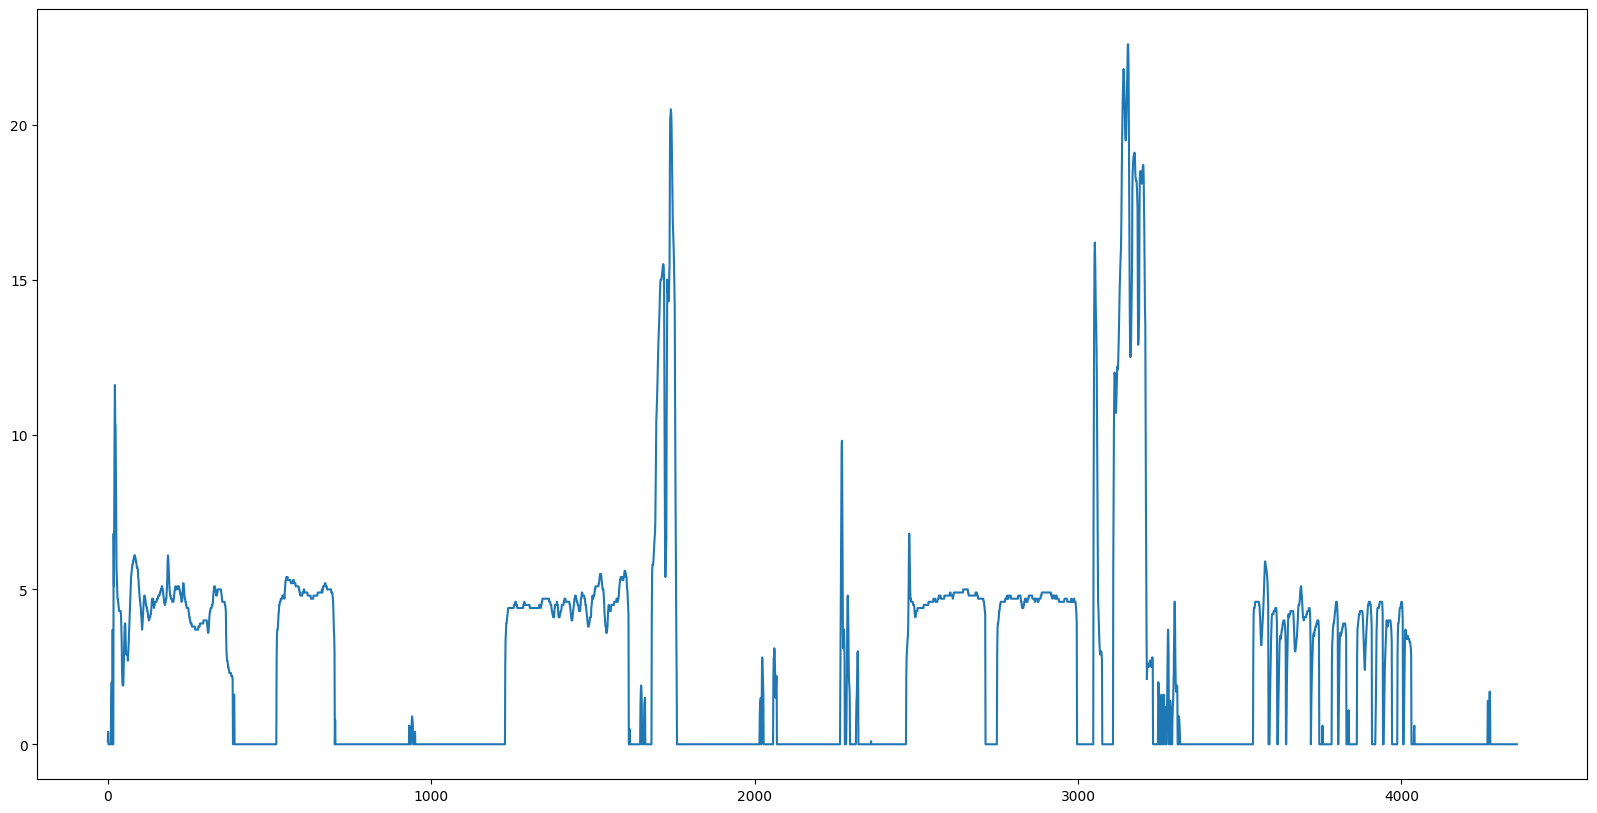

In [21]:
y = Heartrate_Date_2025_11_16_Time_14_48_22["Speed (km/h)"]
x = Heartrate_Date_2025_11_16_Time_14_48_22["Time"]
plt.figure(figsize=(20, 10))
plt.plot(y)
plt.show()

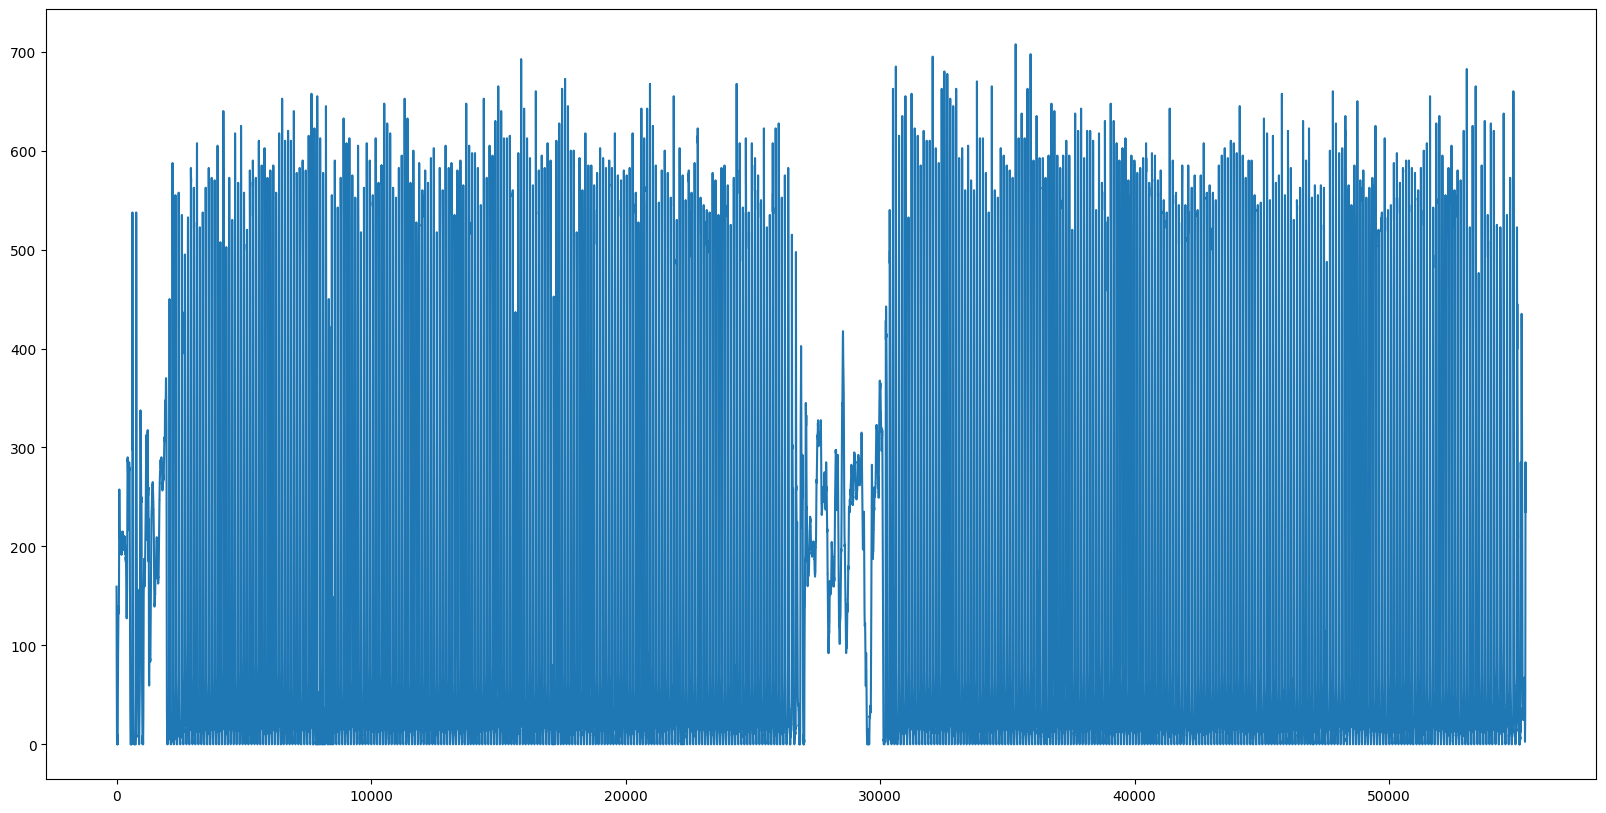

In [33]:
y = globals()[a["name of file"].iloc[2]]["L_Heel"]
plt.figure(figsize=(20, 10))
plt.plot(y)
plt.show()

In [28]:
a

,name of file,Date,Time
23,Forest_Foot_S06P_01_266_Date_2025_11_16_Time_1...,2025_11_16,13_47_50
24,Asphalt_Foot_P06P_01_722_Date_2025_11_16_Time_...,2025_11_16,14_07_55
25,Sand_Foot_S06P_01_178_Date_2025_11_16_Time_14_...,2025_11_16,14_29_02
26,Grass_Foot_P06P_01_845_Date_2025_11_16_Time_14...,2025_11_16,14_46_47


In [29]:
a["name of file"].iloc[2]

'Sand_Foot_S06P_01_178_Date_2025_11_16_Time_14_29_02'